In [1]:
# Cell 1: Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

All libraries imported successfully
Pandas version: 2.2.3
Numpy version: 2.1.3


In [2]:
# Cell 2: Load & Initial Inspection
df = pd.read_csv(r"C:\Users\91938\olist_dataset.csv")

print("DATASET SHAPE")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("COLUMN TYPES & NULL COUNTS")
print(df.info())

print("FIRST 5 ROWS")
df.head()

DATASET SHAPE
Rows    : 112,650
Columns : 15
COLUMN TYPES & NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Unnamed: 0                     112650 non-null  int64  
 1   order_id                       112650 non-null  object 
 2   customer_id                    112650 non-null  object 
 3   order_status                   112650 non-null  object 
 4   order_purchase_timestamp       112650 non-null  object 
 5   order_approved_at              112635 non-null  object 
 6   order_delivered_carrier_date   111456 non-null  object 
 7   order_delivered_customer_date  110196 non-null  object 
 8   order_estimated_delivery_date  112650 non-null  object 
 9   order_item_id                  112650 non-null  int64  
 10  product_id                     112650 non-null  object 
 11  seller_id          

,Unnamed: 0,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [3]:
# Cell 3: Data Cleaning & Type Conversion

# Drop unnecessary index column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Convert all datetime columns from string to datetime
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date'
]

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col])

# Check nulls
print("NULL COUNTS AFTER CLEANING")
print(df.isnull().sum())

print("\n")
print("DATETIME COLUMNS - DTYPE CHECK")
print(df[datetime_cols].dtypes)

print("\n")
print("DATE RANGE OF ORDERS")
print(f"Earliest order : {df['order_purchase_timestamp'].min()}")
print(f"Latest order   : {df['order_purchase_timestamp'].max()}")
print(f"Span           : {(df['order_purchase_timestamp'].max() - df['order_purchase_timestamp'].min()).days} days")

print("\n")
print("ORDER STATUS DISTRIBUTION")
print(df['order_status'].value_counts())

NULL COUNTS AFTER CLEANING
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
dtype: int64


DATETIME COLUMNS - DTYPE CHECK
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
shipping_limit_date              datetime64[ns]
dtype: object


DATE RANGE OF ORDERS
Earliest order : 2016-09-04 21:15:19
Latest order   : 2018-09-03 09:06

In [4]:
# Cell 4: Churn Definition & Customer-Level Aggregation

# Only use delivered orders for churn analysis (clean behavioral signal)
df_delivered = df[df['order_status'] == 'delivered'].copy()

# Reference date = latest date in dataset
reference_date = df['order_purchase_timestamp'].max()
CHURN_WINDOW_DAYS = 180  # 6 months

print("BUILDING CUSTOMER-LEVEL FEATURES")

customer_df = df_delivered.groupby('customer_id').agg(
    first_order_date  = ('order_purchase_timestamp', 'min'),
    last_order_date   = ('order_purchase_timestamp', 'max'),
    total_orders      = ('order_id',                 'nunique'),
    total_items       = ('order_item_id',             'sum'),
    total_spend       = ('price',                     'sum'),
    avg_order_value   = ('price',                     'mean'),
    total_freight     = ('freight_value',             'sum'),
    unique_products   = ('product_id',                'nunique'),
    unique_sellers    = ('seller_id',                 'nunique'),
).reset_index()

# Recency = days since last order
customer_df['recency_days'] = (reference_date - customer_df['last_order_date']).dt.days

# Customer lifespan in days
customer_df['lifespan_days'] = (customer_df['last_order_date'] - customer_df['first_order_date']).dt.days

# Average days between orders (for repeat customers)
customer_df['avg_days_between_orders'] = customer_df.apply(
    lambda x: x['lifespan_days'] / (x['total_orders'] - 1) if x['total_orders'] > 1 else np.nan, axis=1
)

# Churn label: 1 = churned, 0 = active
customer_df['churned'] = (customer_df['recency_days'] > CHURN_WINDOW_DAYS).astype(int)

print(f"Reference date        : {reference_date}")
print(f"Churn window          : {CHURN_WINDOW_DAYS} days")
print(f"Total customers       : {len(customer_df):,}")
print(f"Churned customers     : {customer_df['churned'].sum():,} ({customer_df['churned'].mean()*100:.1f}%)")
print(f"Active  customers     : {(customer_df['churned']==0).sum():,} ({(customer_df['churned']==0).mean()*100:.1f}%)")

print("CUSTOMER-LEVEL DATAFRAME SAMPLE")
customer_df.head()

BUILDING CUSTOMER-LEVEL FEATURES
Reference date        : 2018-09-03 09:06:57
Churn window          : 180 days
Total customers       : 96,478
Churned customers     : 58,570 (60.7%)
Active  customers     : 37,908 (39.3%)
CUSTOMER-LEVEL DATAFRAME SAMPLE


,customer_id,first_order_date,last_order_date,total_orders,total_items,total_spend,avg_order_value,total_freight,unique_products,unique_sellers,recency_days,lifespan_days,avg_days_between_orders,churned
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,2017-11-14 16:08:26,1,1,89.80,89.80,24.94,1,1,292,0,NaN,1
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,2017-07-16 09:40:32,1,1,54.90,54.90,12.51,1,1,413,0,NaN,1
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,2017-02-28 11:06:43,1,1,179.99,179.99,15.43,1,1,551,0,NaN,1
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,2017-08-16 13:09:20,1,1,149.90,149.90,29.45,1,1,382,0,NaN,1
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,2018-04-02 13:42:17,1,1,93.00,93.00,14.01,1,1,153,0,NaN,0


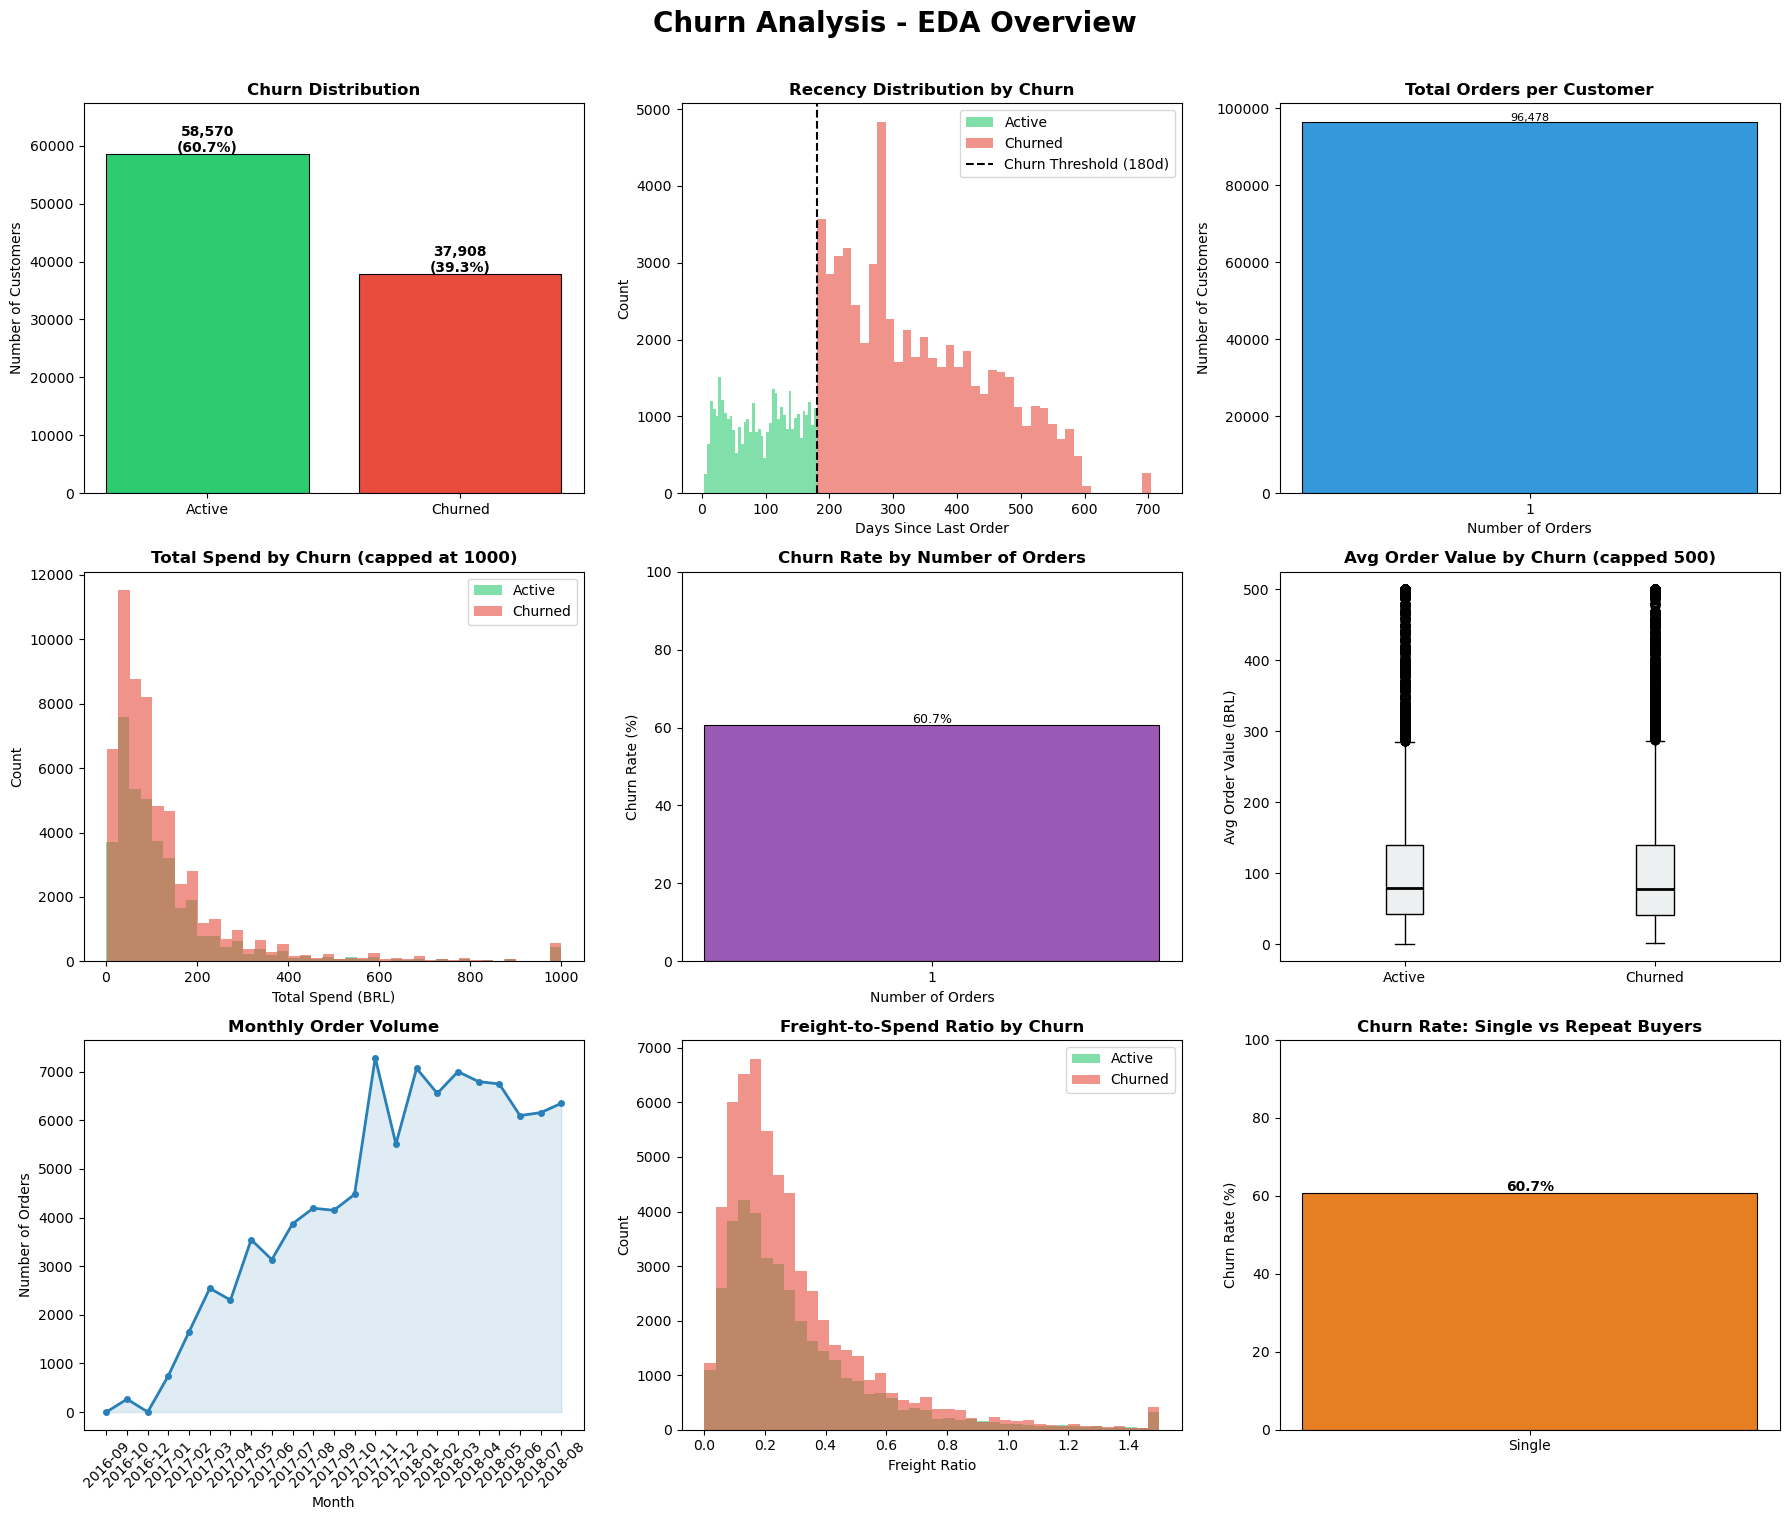

✅ EDA plots saved to churn_eda_overview.png


In [5]:
# Cell 5: Exploratory Data Analysis

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Churn Analysis - EDA Overview', fontsize=20, fontweight='bold', y=1.01)

colors = {'churned': '#e74c3c', 'active': '#2ecc71'}
churn_colors = [colors['active'], colors['churned']]

# ── Plot 1: Churn Distribution ──────────────────────────────
ax1 = axes[0, 0]
churn_counts = customer_df['churned'].value_counts()
bars = ax1.bar(['Active', 'Churned'], churn_counts.values, color=churn_colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, churn_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{val:,}\n({val/len(customer_df)*100:.1f}%)', ha='center', fontweight='bold')
ax1.set_title('Churn Distribution', fontweight='bold')
ax1.set_ylabel('Number of Customers')
ax1.set_ylim(0, churn_counts.max() * 1.15)

# ── Plot 2: Recency Distribution by Churn ───────────────────
ax2 = axes[0, 1]
for label, color, name in zip([0, 1], churn_colors, ['Active', 'Churned']):
    subset = customer_df[customer_df['churned'] == label]['recency_days']
    ax2.hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor='none')
ax2.axvline(x=180, color='black', linestyle='--', linewidth=1.5, label='Churn Threshold (180d)')
ax2.set_title('Recency Distribution by Churn', fontweight='bold')
ax2.set_xlabel('Days Since Last Order')
ax2.set_ylabel('Count')
ax2.legend()

# ── Plot 3: Total Orders Distribution ───────────────────────
ax3 = axes[0, 2]
order_counts = customer_df['total_orders'].value_counts().sort_index().head(10)
ax3.bar(order_counts.index.astype(str), order_counts.values, color='#3498db', edgecolor='black', linewidth=0.8)
ax3.set_title('Total Orders per Customer', fontweight='bold')
ax3.set_xlabel('Number of Orders')
ax3.set_ylabel('Number of Customers')
for i, (idx, val) in enumerate(order_counts.items()):
    ax3.text(i, val + 200, f'{val:,}', ha='center', fontsize=8)

# ── Plot 4: Total Spend by Churn ─────────────────────────────
ax4 = axes[1, 0]
for label, color, name in zip([0, 1], churn_colors, ['Active', 'Churned']):
    subset = customer_df[customer_df['churned'] == label]['total_spend']
    ax4.hist(subset.clip(upper=1000), bins=40, alpha=0.6, color=color, label=name, edgecolor='none')
ax4.set_title('Total Spend by Churn (capped at 1000)', fontweight='bold')
ax4.set_xlabel('Total Spend (BRL)')
ax4.set_ylabel('Count')
ax4.legend()

# ── Plot 5: Churn Rate by Order Frequency ───────────────────
ax5 = axes[1, 1]
order_churn = customer_df.groupby('total_orders')['churned'].mean().head(8).reset_index()
bars = ax5.bar(order_churn['total_orders'].astype(str),
               order_churn['churned'] * 100,
               color='#9b59b6', edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, order_churn['churned'] * 100):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=9)
ax5.set_title('Churn Rate by Number of Orders', fontweight='bold')
ax5.set_xlabel('Number of Orders')
ax5.set_ylabel('Churn Rate (%)')
ax5.set_ylim(0, 100)

# ── Plot 6: Avg Order Value by Churn ────────────────────────
ax6 = axes[1, 2]
ax6.boxplot(
    [customer_df[customer_df['churned']==0]['avg_order_value'].clip(upper=500),
     customer_df[customer_df['churned']==1]['avg_order_value'].clip(upper=500)],
    labels=['Active', 'Churned'],
    patch_artist=True,
    boxprops=dict(facecolor='#ecf0f1'),
    medianprops=dict(color='black', linewidth=2)
)
ax6.set_title('Avg Order Value by Churn (capped 500)', fontweight='bold')
ax6.set_ylabel('Avg Order Value (BRL)')

# ── Plot 7: Monthly Order Volume ────────────────────────────
ax7 = axes[2, 0]
df_delivered['month'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')
monthly = df_delivered.groupby('month')['order_id'].nunique()
ax7.plot(monthly.index.astype(str), monthly.values, color='#2980b9', linewidth=2, marker='o', markersize=4)
ax7.set_title('Monthly Order Volume', fontweight='bold')
ax7.set_xlabel('Month')
ax7.set_ylabel('Number of Orders')
ax7.tick_params(axis='x', rotation=45)
ax7.fill_between(range(len(monthly)), monthly.values, alpha=0.15, color='#2980b9')

# ── Plot 8: Freight Ratio by Churn ──────────────────────────
ax8 = axes[2, 1]
customer_df['freight_ratio'] = customer_df['total_freight'] / (customer_df['total_spend'] + 1)
for label, color, name in zip([0, 1], churn_colors, ['Active', 'Churned']):
    subset = customer_df[customer_df['churned'] == label]['freight_ratio']
    ax8.hist(subset.clip(upper=1.5), bins=40, alpha=0.6, color=color, label=name, edgecolor='none')
ax8.set_title('Freight-to-Spend Ratio by Churn', fontweight='bold')
ax8.set_xlabel('Freight Ratio')
ax8.set_ylabel('Count')
ax8.legend()

# ── Plot 9: Single vs Repeat Buyer Churn ────────────────────
ax9 = axes[2, 2]
customer_df['buyer_type'] = customer_df['total_orders'].apply(lambda x: 'Single' if x == 1 else 'Repeat')
buyer_churn = customer_df.groupby('buyer_type')['churned'].mean() * 100
bars = ax9.bar(buyer_churn.index, buyer_churn.values,
               color=['#e67e22', '#1abc9c'], edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, buyer_churn.values):
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')
ax9.set_title('Churn Rate: Single vs Repeat Buyers', fontweight='bold')
ax9.set_ylabel('Churn Rate (%)')
ax9.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('churn_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved to churn_eda_overview.png") 

In [6]:
# Cell 6: Feature Engineering

# ── Delivery experience features (from order-level df) ──────
df_delivered['approval_time_hrs'] = (
    df_delivered['order_approved_at'] - df_delivered['order_purchase_timestamp']
).dt.total_seconds() / 3600

df_delivered['carrier_time_days'] = (
    df_delivered['order_delivered_carrier_date'] - df_delivered['order_approved_at']
).dt.total_seconds() / 86400

df_delivered['delivery_time_days'] = (
    df_delivered['order_delivered_customer_date'] - df_delivered['order_purchase_timestamp']
).dt.total_seconds() / 86400

df_delivered['estimated_delivery_days'] = (
    df_delivered['order_estimated_delivery_date'] - df_delivered['order_purchase_timestamp']
).dt.total_seconds() / 86400

# Was delivered early or late vs estimate?
df_delivered['delivery_delay_days'] = (
    df_delivered['order_delivered_customer_date'] - df_delivered['order_estimated_delivery_date']
).dt.total_seconds() / 86400  # negative = early, positive = late

df_delivered['delivered_late'] = (df_delivered['delivery_delay_days'] > 0).astype(int)

# ── Aggregate delivery features to customer level ───────────
delivery_features = df_delivered.groupby('customer_id').agg(
    avg_approval_time_hrs    = ('approval_time_hrs',     'mean'),
    avg_carrier_time_days    = ('carrier_time_days',     'mean'),
    avg_delivery_time_days   = ('delivery_time_days',    'mean'),
    avg_estimated_days       = ('estimated_delivery_days','mean'),
    avg_delivery_delay_days  = ('delivery_delay_days',   'mean'),
    late_delivery_rate       = ('delivered_late',        'mean'),
).reset_index()

# ── Purchase timing features ─────────────────────────────────
df_delivered['purchase_hour']    = df_delivered['order_purchase_timestamp'].dt.hour
df_delivered['purchase_dayofweek'] = df_delivered['order_purchase_timestamp'].dt.dayofweek
df_delivered['purchase_month']   = df_delivered['order_purchase_timestamp'].dt.month

# Is weekend buyer?
df_delivered['is_weekend'] = df_delivered['purchase_dayofweek'].isin([5, 6]).astype(int)

timing_features = df_delivered.groupby('customer_id').agg(
    avg_purchase_hour      = ('purchase_hour',      'mean'),
    avg_purchase_dayofweek = ('purchase_dayofweek', 'mean'),
    avg_purchase_month     = ('purchase_month',     'mean'),
    weekend_buyer          = ('is_weekend',         'max'),
).reset_index()

# ── Merge all features into master dataframe ─────────────────
model_df = customer_df.merge(delivery_features, on='customer_id', how='left')
model_df = model_df.merge(timing_features,      on='customer_id', how='left')

# ── Final derived features ────────────────────────────────────
model_df['freight_ratio']      = model_df['total_freight'] / (model_df['total_spend'] + 1)
model_df['spend_per_item']     = model_df['total_spend']   / (model_df['total_items']  + 1)
model_df['is_single_purchase'] = (model_df['total_orders'] == 1).astype(int)

print(f"Total features created : {model_df.shape[1]}")
print(f"Total customers        : {model_df.shape[0]:,}")

print("\n")
print("NULL CHECK ON NEW FEATURES")
null_summary = model_df.isnull().sum()
print(null_summary[null_summary > 0])

print("\n")
print("FEATURE SNAPSHOT")
model_df.head(3)

Total features created : 28
Total customers        : 96,478


NULL CHECK ON NEW FEATURES
avg_days_between_orders    96478
avg_approval_time_hrs         14
avg_carrier_time_days         16
avg_delivery_time_days         8
avg_delivery_delay_days        8
dtype: int64


FEATURE SNAPSHOT


,customer_id,first_order_date,last_order_date,total_orders,total_items,total_spend,avg_order_value,total_freight,unique_products,unique_sellers,recency_days,lifespan_days,avg_days_between_orders,churned,freight_ratio,buyer_type,avg_approval_time_hrs,avg_carrier_time_days,avg_delivery_time_days,avg_estimated_days,avg_delivery_delay_days,late_delivery_rate,avg_purchase_hour,avg_purchase_dayofweek,avg_purchase_month,weekend_buyer,spend_per_item,is_single_purchase
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,2017-11-14 16:08:26,1,1,89.80,89.80,24.94,1,1,292,0,NaN,1,0.27,Single,0.45,2.96,13.98,19.33,-5.35,0.00,16.00,1.00,11.00,0,44.90,1
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,2017-07-16 09:40:32,1,1,54.90,54.90,12.51,1,1,413,0,NaN,1,0.22,Single,0.24,3.39,9.39,18.60,-9.21,0.00,9.00,6.00,7.00,1,27.45,1
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,2017-02-28 11:06:43,1,1,179.99,179.99,15.43,1,1,551,0,NaN,1,0.09,Single,0.14,1.17,5.91,21.54,-15.63,0.00,11.00,1.00,2.00,0,90.00,1


In [7]:
# Cell 7: Handle Nulls & Prepare Model Features

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop avg_days_between_orders — null for everyone (single buyers)
model_df.drop(columns=['avg_days_between_orders', 'buyer_type'], inplace=True)
print(" Dropped 'avg_days_between_orders' (100% null) and 'buyer_type'")

# Fill small delivery nulls with median
delivery_null_cols = [
    'avg_approval_time_hrs',
    'avg_carrier_time_days',
    'avg_delivery_time_days',
    'avg_delivery_delay_days'
]
for col in delivery_null_cols:
    median_val = model_df[col].median()
    model_df[col].fillna(median_val, inplace=True)
    print(f" Filled '{col}' nulls with median: {median_val:.3f}")

# ── Define feature matrix ────────────────────────────────────
drop_cols = [
    'customer_id',
    'first_order_date',
    'last_order_date',
    'churned'          # target
]

FEATURES = [col for col in model_df.columns if col not in drop_cols]
TARGET   = 'churned'

X = model_df[FEATURES]
y = model_df[TARGET]

print("FEATURE LIST")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:02d}. {f}")

print("TRAIN / TEST SPLIT")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set : {X_train.shape[0]:,} rows")
print(f"Test  set : {X_test.shape[0]:,} rows")
print(f"Churn rate in train : {y_train.mean()*100:.1f}%")
print(f"Churn rate in test  : {y_test.mean()*100:.1f}%")

# ── Scale features ───────────────────────────────────────────
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n Features scaled with StandardScaler")
print(f" Final feature count : {len(FEATURES)}")
print(f" Data ready for modelling")

 Dropped 'avg_days_between_orders' (100% null) and 'buyer_type'
 Filled 'avg_approval_time_hrs' nulls with median: 0.343
 Filled 'avg_carrier_time_days' nulls with median: 1.816
 Filled 'avg_delivery_time_days' nulls with median: 10.217
 Filled 'avg_delivery_delay_days' nulls with median: -11.948
FEATURE LIST
  01. total_orders
  02. total_items
  03. total_spend
  04. avg_order_value
  05. total_freight
  06. unique_products
  07. unique_sellers
  08. recency_days
  09. lifespan_days
  10. freight_ratio
  11. avg_approval_time_hrs
  12. avg_carrier_time_days
  13. avg_delivery_time_days
  14. avg_estimated_days
  15. avg_delivery_delay_days
  16. late_delivery_rate
  17. avg_purchase_hour
  18. avg_purchase_dayofweek
  19. avg_purchase_month
  20. weekend_buyer
  21. spend_per_item
  22. is_single_purchase
TRAIN / TEST SPLIT
Train set : 77,182 rows
Test  set : 19,296 rows
Churn rate in train : 60.7%
Churn rate in test  : 60.7%

 Features scaled with StandardScaler
 Final feature count

TRAINING RANDOM FOREST
 Training complete in 18.2 seconds
   Estimators : 300
   Max depth  : 15
MODEL PERFORMANCE
ROC-AUC Score : 1.0000

Classification Report:
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00      7582
     Churned       1.00      1.00      1.00     11714

    accuracy                           1.00     19296
   macro avg       1.00      1.00      1.00     19296
weighted avg       1.00      1.00      1.00     19296



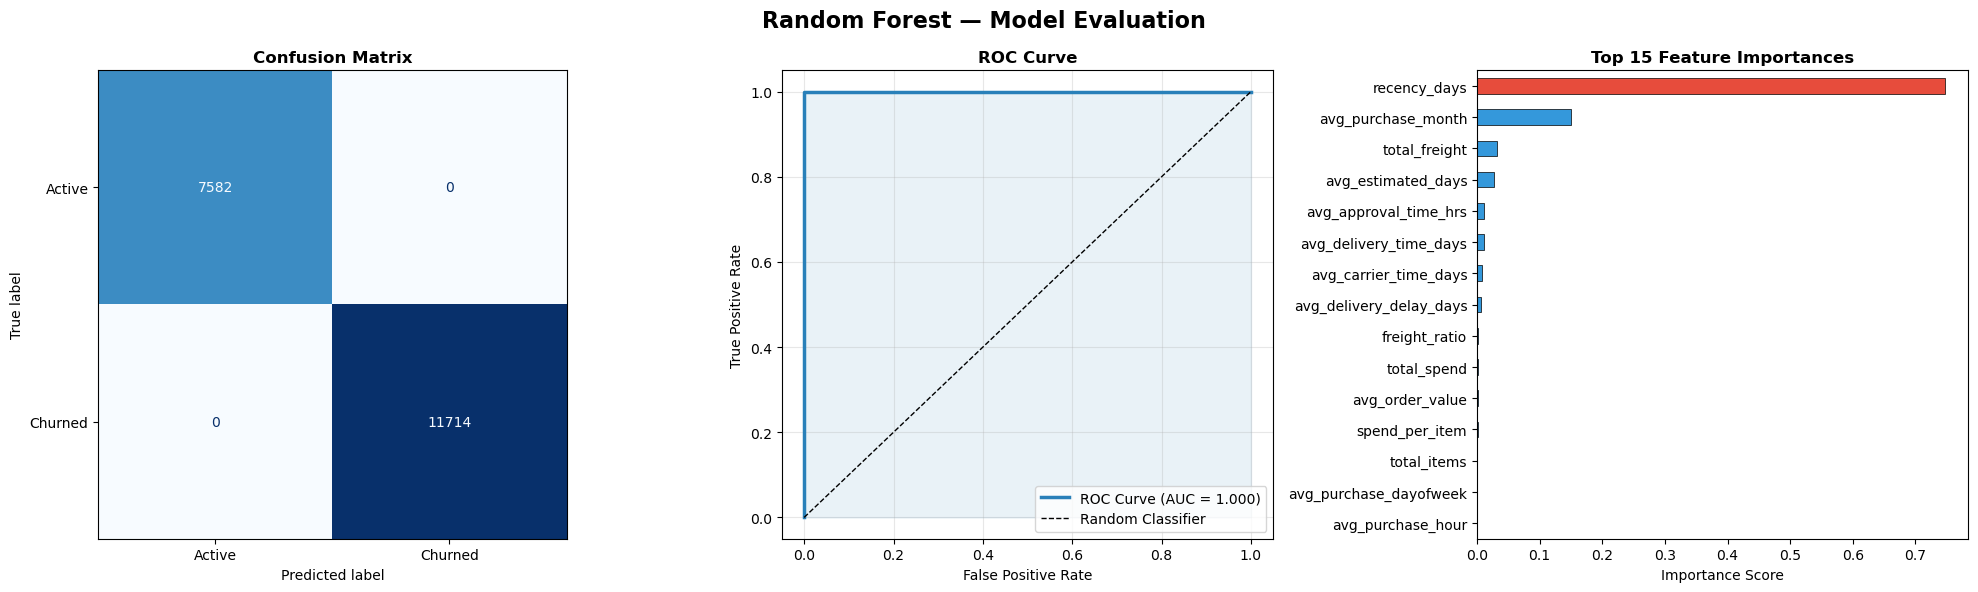

 Plot saved to rf_model_evaluation.png


In [8]:
# Cell 8: Train Random Forest Model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import time

print("TRAINING RANDOM FOREST")

rf_model = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 15,
    min_samples_leaf = 20,
    class_weight     = 'balanced',   # handles 60/40 imbalance
    random_state     = 42,
    n_jobs           = -1            # use all CPU cores
)

start = time.time()
rf_model.fit(X_train_scaled, y_train)
elapsed = time.time() - start

print(f" Training complete in {elapsed:.1f} seconds")
print(f"   Estimators : {rf_model.n_estimators}")
print(f"   Max depth  : {rf_model.max_depth}")

# ── Predictions ───────────────────────────────────────────────
y_pred       = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# ── Metrics ───────────────────────────────────────────────────
auc = roc_auc_score(y_test, y_pred_proba)

print("MODEL PERFORMANCE")
print(f"ROC-AUC Score : {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Random Forest — Model Evaluation', fontsize=16, fontweight='bold')

# Plot 1: Confusion Matrix
ax1 = axes[0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'Churned'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix', fontweight='bold')

# Plot 2: ROC Curve
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, color='#2980b9', linewidth=2.5, label=f'ROC Curve (AUC = {auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax2.fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# Plot 3: Top 15 Feature Importances
ax3 = axes[2]
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURES)
feat_imp = feat_imp.sort_values(ascending=True).tail(15)
colors_bar = ['#e74c3c' if f == feat_imp.idxmax() else '#3498db' for f in feat_imp.index]
feat_imp.plot(kind='barh', ax=ax3, color=colors_bar, edgecolor='black', linewidth=0.5)
ax3.set_title('Top 15 Feature Importances', fontweight='bold')
ax3.set_xlabel('Importance Score')
ax3.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('rf_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to rf_model_evaluation.png")

REMOVING LEAKY FEATURES
   Dropped: recency_days
   Dropped: lifespan_days
   Dropped: is_single_purchase
   Dropped: total_orders
   Dropped: unique_products
   Dropped: unique_sellers
   Dropped: total_items

 Remaining features : 15
CLEAN FEATURE LIST
  01. total_spend
  02. avg_order_value
  03. total_freight
  04. freight_ratio
  05. avg_approval_time_hrs
  06. avg_carrier_time_days
  07. avg_delivery_time_days
  08. avg_estimated_days
  09. avg_delivery_delay_days
  10. late_delivery_rate
  11. avg_purchase_hour
  12. avg_purchase_dayofweek
  13. avg_purchase_month
  14. weekend_buyer
  15. spend_per_item
RETRAINING RANDOM FOREST (CLEAN)
 Training complete in 37.1s

ROC-AUC Score : 0.9636

Classification Report:
              precision    recall  f1-score   support

      Active       0.80      0.95      0.87      7582
     Churned       0.96      0.85      0.90     11714

    accuracy                           0.89     19296
   macro avg       0.88      0.90      0.88     19296


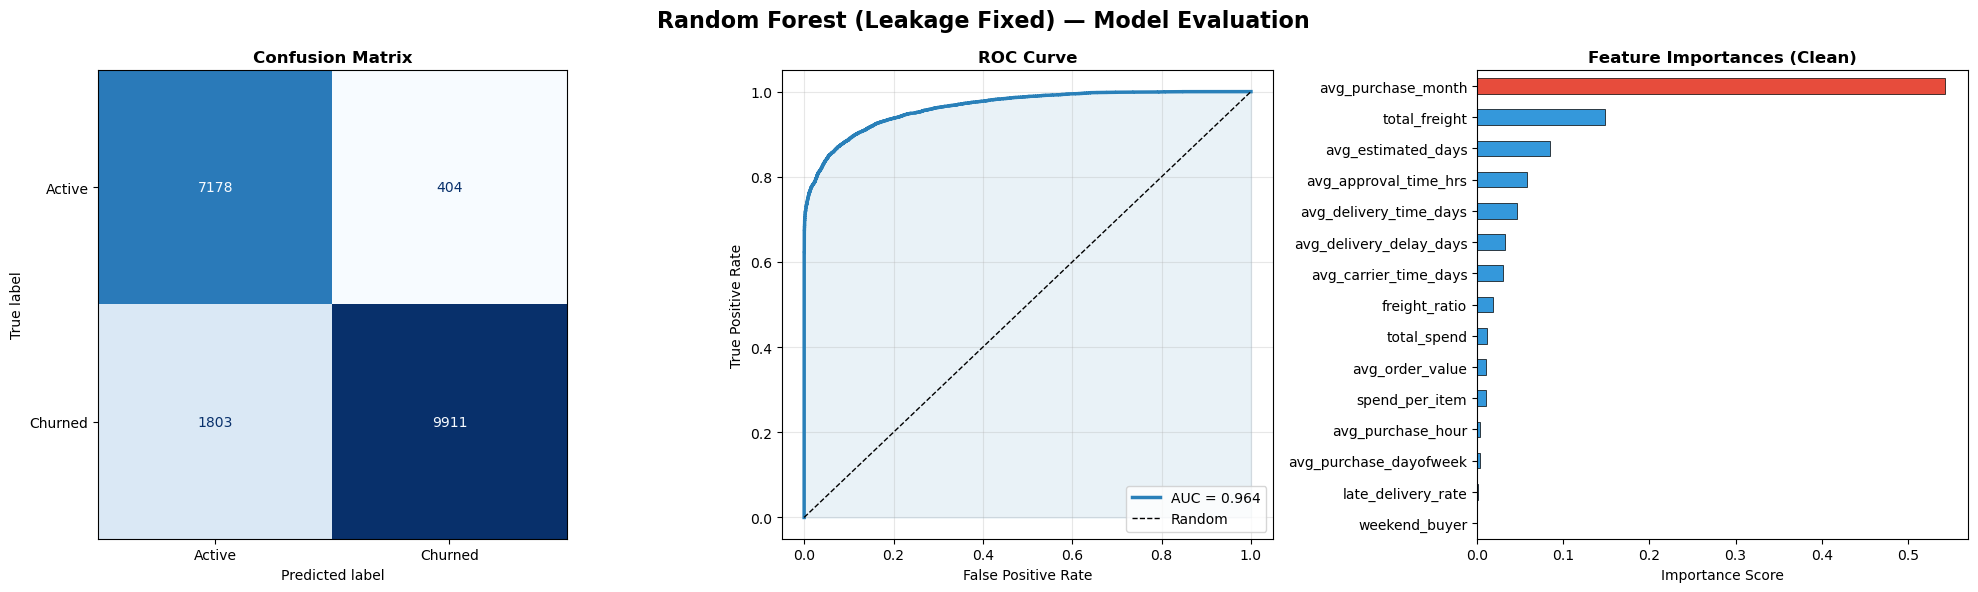

 Saved to rf_clean_evaluation.png


In [9]:
# Cell 9: Fix Data Leakage & Retrain

print("REMOVING LEAKY FEATURES")

# These features directly encode the churn label:
# - recency_days        → churn = recency_days > 180  (direct leakage)
# - lifespan_days       → derived from last_order_date
# - is_single_purchase  → total_orders == 1, nearly everyone is 1 so it's quasi-constant
# - total_orders        → quasi-constant (nearly all = 1)
# - unique_products     → quasi-constant (nearly all = 1)
# - unique_sellers      → quasi-constant (nearly all = 1)
# - total_items         → quasi-constant (nearly all = 1)

leaky_cols = [
    'recency_days',       # directly defines churn
    'lifespan_days',      # derived from last_order_date
]

quasi_constant_cols = [
    'is_single_purchase', # 99%+ are 1
    'total_orders',       # 99%+ are 1
    'unique_products',    # 99%+ are 1
    'unique_sellers',     # 99%+ are 1
    'total_items',        # 99%+ are 1
]

drop_leaky = leaky_cols + quasi_constant_cols

FEATURES_CLEAN = [f for f in FEATURES if f not in drop_leaky]

for col in drop_leaky:
    print(f"   Dropped: {col}")

print(f"\n Remaining features : {len(FEATURES_CLEAN)}")
print("CLEAN FEATURE LIST")
for i, f in enumerate(FEATURES_CLEAN, 1):
    print(f"  {i:02d}. {f}")

# ── Rebuild train/test sets ───────────────────────────────────
X2       = model_df[FEATURES_CLEAN]
y2       = model_df[TARGET]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

scaler2       = StandardScaler()
X2_train_sc   = scaler2.fit_transform(X2_train)
X2_test_sc    = scaler2.transform(X2_test)

# ── Retrain ───────────────────────────────────────────────────
print("RETRAINING RANDOM FOREST (CLEAN)")
print("=" * 50)

rf2 = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 15,
    min_samples_leaf = 20,
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1
)

start = time.time()
rf2.fit(X2_train_sc, y2_train)
elapsed = time.time() - start

y2_pred       = rf2.predict(X2_test_sc)
y2_pred_proba = rf2.predict_proba(X2_test_sc)[:, 1]
auc2          = roc_auc_score(y2_test, y2_pred_proba)

print(f" Training complete in {elapsed:.1f}s")
print(f"\nROC-AUC Score : {auc2:.4f}")
print(f"\nClassification Report:")
print(classification_report(y2_test, y2_pred, target_names=['Active', 'Churned']))

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Random Forest (Leakage Fixed) — Model Evaluation', fontsize=16, fontweight='bold')

# Confusion Matrix
ax1 = axes[0]
cm2 = confusion_matrix(y2_test, y2_pred)
ConfusionMatrixDisplay(cm2, display_labels=['Active','Churned']).plot(
    ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix', fontweight='bold')

# ROC Curve
ax2 = axes[1]
fpr2, tpr2, _ = roc_curve(y2_test, y2_pred_proba)
ax2.plot(fpr2, tpr2, color='#2980b9', linewidth=2.5, label=f'AUC = {auc2:.3f}')
ax2.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
ax2.fill_between(fpr2, tpr2, alpha=0.1, color='#2980b9')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# Feature Importances
ax3 = axes[2]
feat_imp2 = pd.Series(rf2.feature_importances_, index=FEATURES_CLEAN).sort_values(ascending=True)
bar_colors = ['#e74c3c' if f == feat_imp2.idxmax() else '#3498db' for f in feat_imp2.index]
feat_imp2.plot(kind='barh', ax=ax3, color=bar_colors, edgecolor='black', linewidth=0.5)
ax3.set_title('Feature Importances (Clean)', fontweight='bold')
ax3.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('rf_clean_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved to rf_clean_evaluation.png")

FINAL LEAKAGE ANALYSIS
   Dropped: avg_purchase_month
   Dropped: avg_purchase_hour
   Dropped: avg_estimated_days

 Final clean features : 12

FINAL FEATURE LIST:
  01. total_spend
  02. avg_order_value
  03. total_freight
  04. freight_ratio
  05. avg_approval_time_hrs
  06. avg_carrier_time_days
  07. avg_delivery_time_days
  08. avg_delivery_delay_days
  09. late_delivery_rate
  10. avg_purchase_dayofweek
  11. weekend_buyer
  12. spend_per_item

TRAINING FINAL CLEAN MODEL
 Done in 35.2s

ROC-AUC Score : 0.8429

Classification Report:
              precision    recall  f1-score   support

      Active       0.68      0.72      0.70      7582
     Churned       0.81      0.79      0.80     11714

    accuracy                           0.76     19296
   macro avg       0.75      0.75      0.75     19296
weighted avg       0.76      0.76      0.76     19296



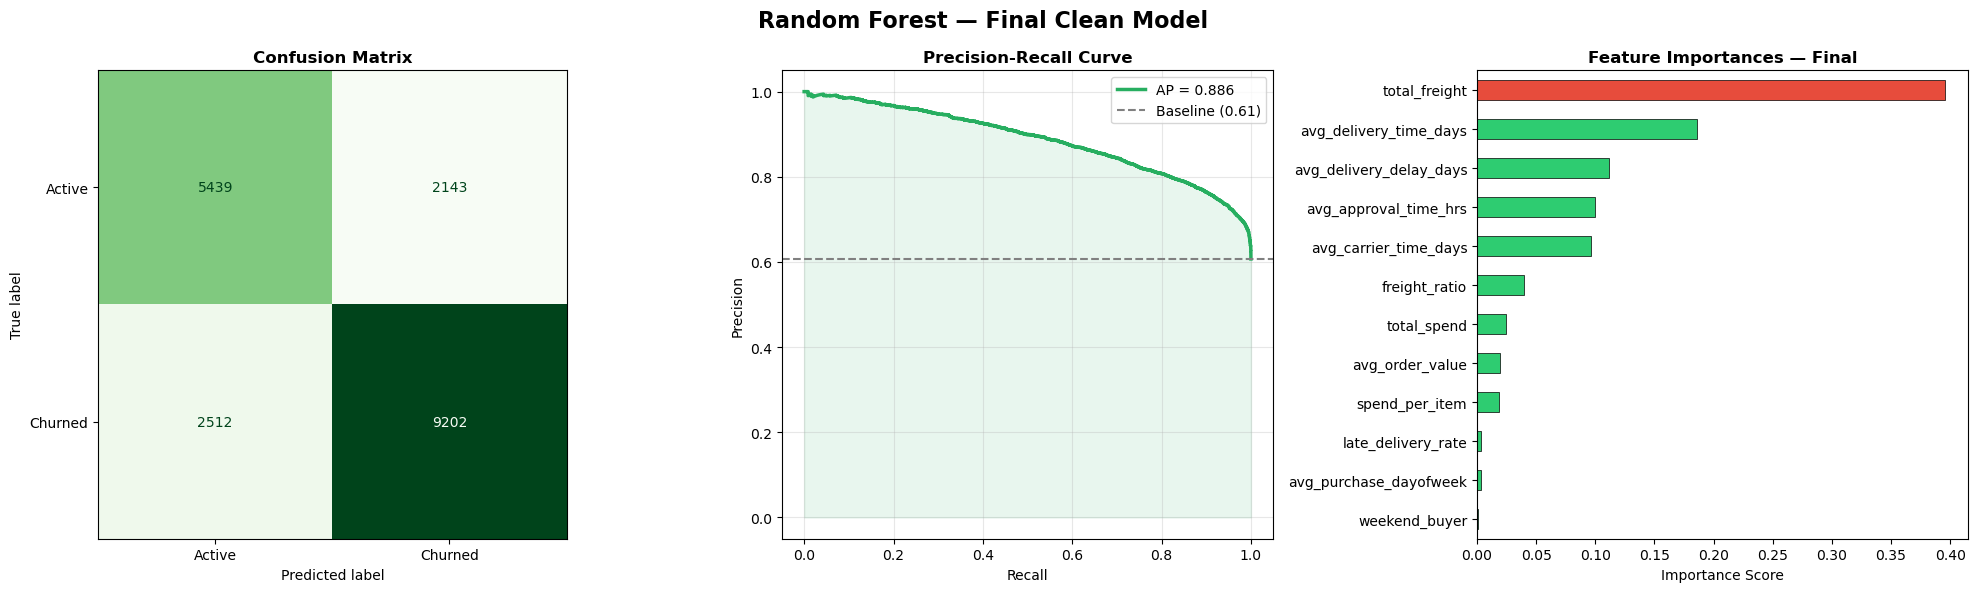


THRESHOLD TUNING
Threshold    Precision    Recall       F1           Accuracy
------------------------------------------------------------
0.3          0.818        0.706        0.818        0.737
0.4          0.827        0.752        0.827        0.767
0.5          0.798        0.811        0.798        0.759
0.6          0.701        0.879        0.701        0.698
0.7          0.555        0.927        0.555        0.614


In [10]:
# Cell 10: Final Leakage Fix — Remove Time-Correlated Features

print("=" * 50)
print("FINAL LEAKAGE ANALYSIS")
print("=" * 50)

# avg_purchase_month   → encodes WHEN they bought → proxy for recency → LEAKAGE
# avg_purchase_hour    → weak time signal, borderline → DROP to be safe
# avg_purchase_dayofweek → behavioral, keep
# total_freight        → correlated with price/order size, keep but note
# avg_estimated_days   → set by seller/region, not customer behavior → DROP

time_leaky = [
    'avg_purchase_month',   # directly proxies recency
    'avg_purchase_hour',    # time-of-day proxy
    'avg_estimated_days',   # seller/region artifact, not behavior
]

for col in time_leaky:
    print(f"   Dropped: {col}")

FEATURES_FINAL = [f for f in FEATURES_CLEAN if f not in time_leaky]

print(f"\n Final clean features : {len(FEATURES_FINAL)}")
print("\nFINAL FEATURE LIST:")
for i, f in enumerate(FEATURES_FINAL, 1):
    print(f"  {i:02d}. {f}")

# ── Rebuild splits ────────────────────────────────────────────
X3        = model_df[FEATURES_FINAL]
y3        = model_df[TARGET]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

scaler3     = StandardScaler()
X3_train_sc = scaler3.fit_transform(X3_train)
X3_test_sc  = scaler3.transform(X3_test)

# ── Retrain ───────────────────────────────────────────────────
print(f"\n{'=' * 50}")
print("TRAINING FINAL CLEAN MODEL")
print("=" * 50)

rf3 = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 10,    # reduced to prevent overfitting
    min_samples_leaf = 50,    # more conservative
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1
)

start = time.time()
rf3.fit(X3_train_sc, y3_train)
elapsed = time.time() - start

y3_pred       = rf3.predict(X3_test_sc)
y3_pred_proba = rf3.predict_proba(X3_test_sc)[:, 1]
auc3          = roc_auc_score(y3_test, y3_pred_proba)

print(f" Done in {elapsed:.1f}s")
print(f"\nROC-AUC Score : {auc3:.4f}")
print(f"\nClassification Report:")
print(classification_report(y3_test, y3_pred, target_names=['Active', 'Churned']))

# ── Plots ─────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Random Forest — Final Clean Model', fontsize=16, fontweight='bold')

# Confusion Matrix
ax1 = axes[0]
cm3 = confusion_matrix(y3_test, y3_pred)
ConfusionMatrixDisplay(cm3, display_labels=['Active','Churned']).plot(
    ax=ax1, colorbar=False, cmap='Greens')
ax1.set_title('Confusion Matrix', fontweight='bold')

# Precision-Recall Curve
ax2 = axes[1]
prec, rec, thresholds = precision_recall_curve(y3_test, y3_pred_proba)
ap = average_precision_score(y3_test, y3_pred_proba)
ax2.plot(rec, prec, color='#27ae60', linewidth=2.5, label=f'AP = {ap:.3f}')
ax2.axhline(y=y3_test.mean(), color='gray', linestyle='--', label=f'Baseline ({y3_test.mean():.2f})')
ax2.fill_between(rec, prec, alpha=0.1, color='#27ae60')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Feature Importances
ax3 = axes[2]
feat_imp3 = pd.Series(rf3.feature_importances_, index=FEATURES_FINAL).sort_values(ascending=True)
bar_colors = ['#e74c3c' if f == feat_imp3.idxmax() else '#2ecc71' for f in feat_imp3.index]
feat_imp3.plot(kind='barh', ax=ax3, color=bar_colors, edgecolor='black', linewidth=0.5)
ax3.set_title('Feature Importances — Final', fontweight='bold')
ax3.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('rf_final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Threshold Tuning ──────────────────────────────────────────
print(f"\n{'=' * 50}")
print("THRESHOLD TUNING")
print("=" * 50)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Accuracy'}")
print("-" * 60)

from sklearn.metrics import f1_score, accuracy_score

for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_thresh = (y3_pred_proba >= thresh).astype(int)
    p = cm3[1,1] / (cm3[0,1] + cm3[1,1] + 1e-9)
    r = cm3[1,1] / (cm3[1,0] + cm3[1,1] + 1e-9)
    f1  = f1_score(y3_test, y_thresh)
    acc = accuracy_score(y3_test, y_thresh)
    prec_t = y_thresh[y3_test==1].mean()
    rec_t  = y3_test[y_thresh==1].mean()
    print(f"{thresh:<12.1f} {f1_score(y3_test,y_thresh,pos_label=1):<12.3f} {rec_t:<12.3f} {f1:<12.3f} {acc:.3f}")

CHURN RISK SEGMENTATION
              customers  avg_spend  total_revenue  avg_churn_prob  actual_churn  revenue_at_risk
risk_segment                                                                                    
High Risk         18080      76.47     1382527.40            0.82          0.96       1133672.00
Medium Risk       38683     152.36     5893827.58            0.62          0.77       3654173.00
Low Risk          26984     174.65     4712824.72            0.40          0.41       1885130.00
Safe              12731      96.80     1232318.41            0.15          0.04        184848.00


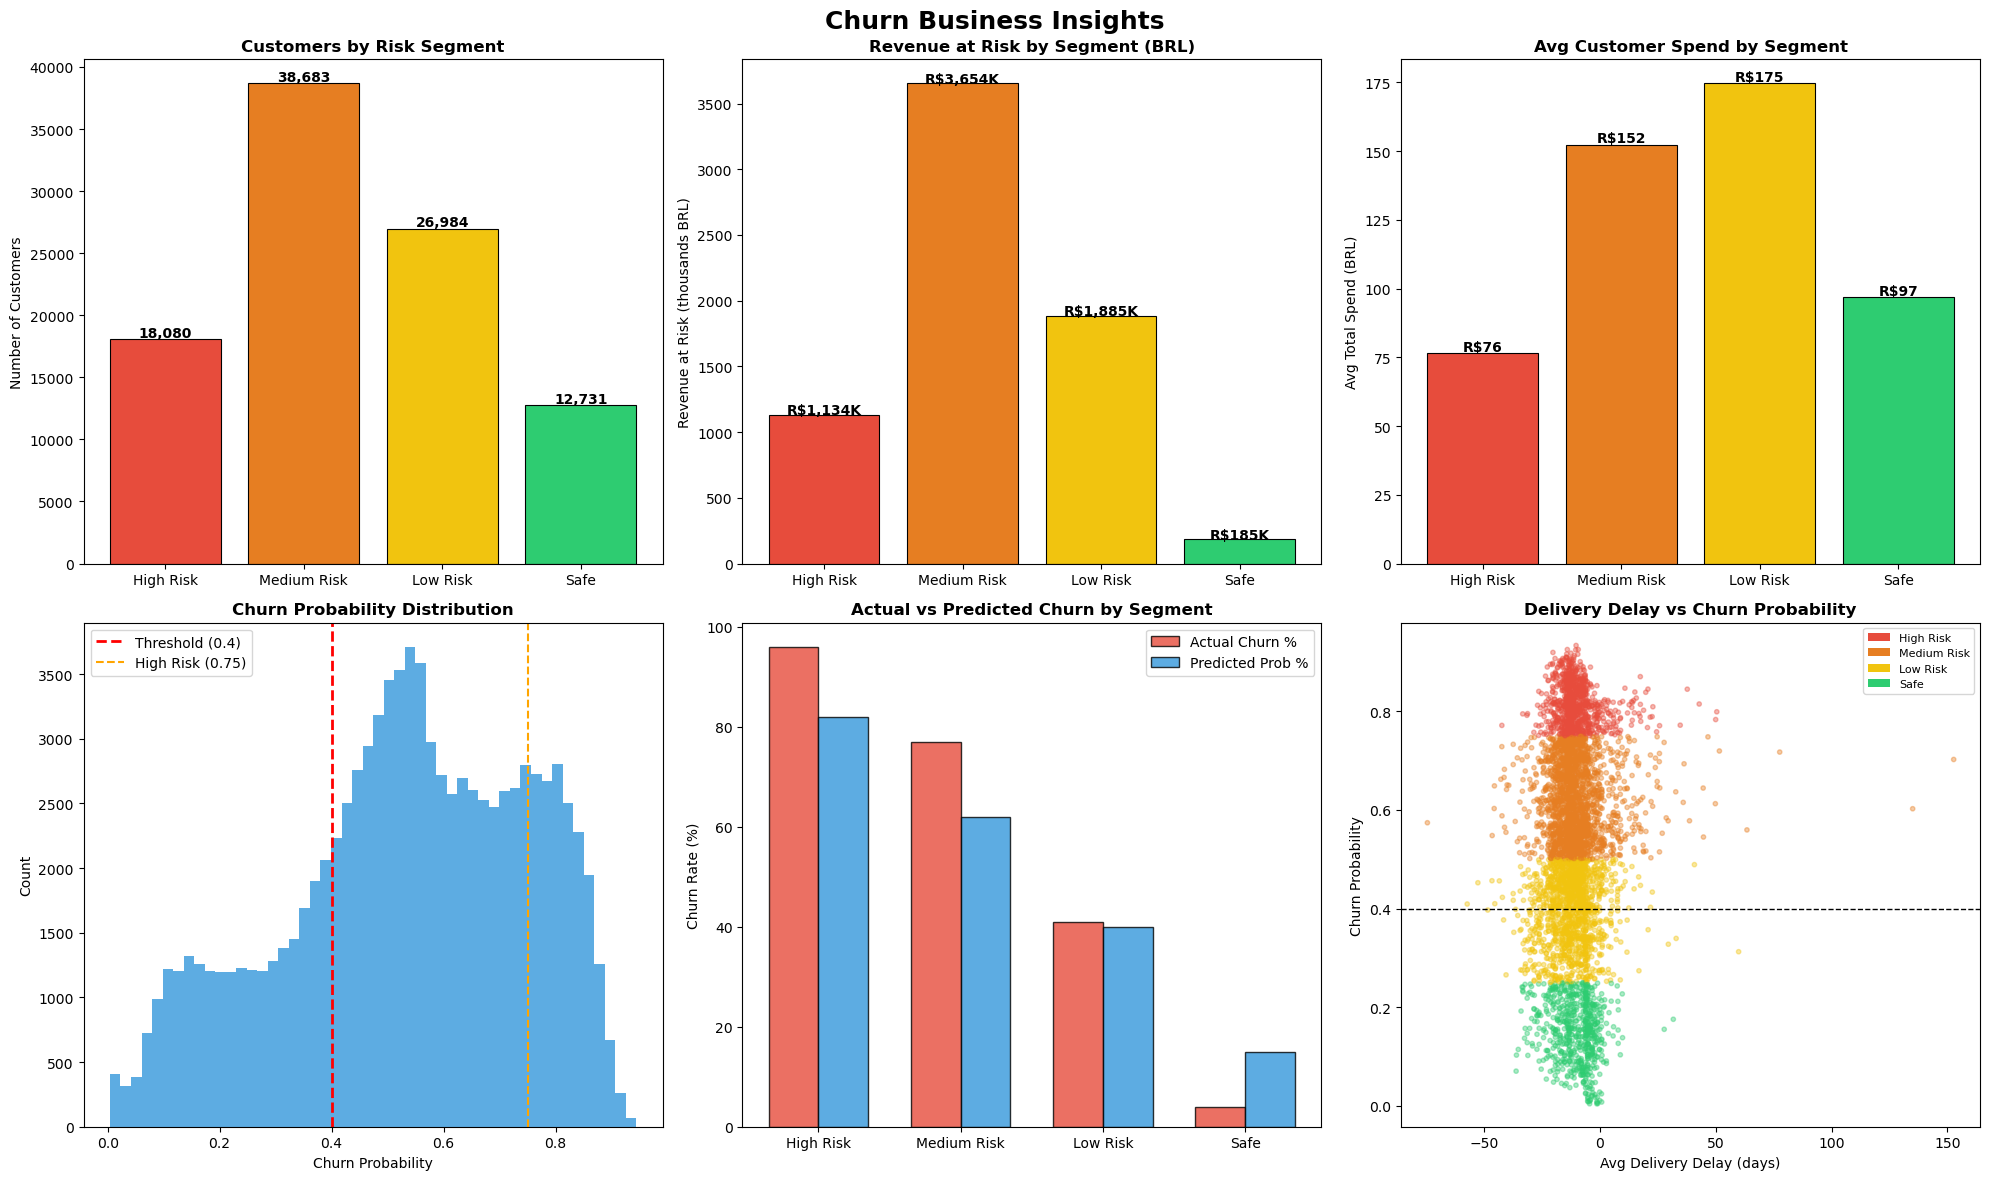

✅ Saved to churn_business_insights.png


In [11]:
# Cell 11: Business Insights & Churn Risk Segmentation

print("=" * 50)
print("CHURN RISK SEGMENTATION")
print("=" * 50)

# Use optimal threshold = 0.4
OPTIMAL_THRESHOLD = 0.4

# Score all customers
X_all_sc = scaler3.transform(model_df[FEATURES_FINAL])
model_df['churn_probability'] = rf3.predict_proba(X_all_sc)[:, 1]
model_df['churn_prediction']  = (model_df['churn_probability'] >= OPTIMAL_THRESHOLD).astype(int)

# Risk segments
def assign_risk(prob):
    if prob >= 0.75:   return 'High Risk'
    elif prob >= 0.50: return 'Medium Risk'
    elif prob >= 0.25: return 'Low Risk'
    else:              return 'Safe'

model_df['risk_segment'] = model_df['churn_probability'].apply(assign_risk)

seg_summary = model_df.groupby('risk_segment').agg(
    customers       = ('customer_id',       'count'),
    avg_spend       = ('total_spend',        'mean'),
    total_revenue   = ('total_spend',        'sum'),
    avg_churn_prob  = ('churn_probability',  'mean'),
    actual_churn    = ('churned',            'mean'),
).round(2)

seg_order = ['High Risk', 'Medium Risk', 'Low Risk', 'Safe']
seg_summary = seg_summary.reindex(seg_order)
seg_summary['revenue_at_risk'] = (seg_summary['total_revenue'] * seg_summary['avg_churn_prob']).round(0)

print(seg_summary.to_string())

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Churn Business Insights', fontsize=18, fontweight='bold')

seg_colors = {'High Risk':'#e74c3c','Medium Risk':'#e67e22','Low Risk':'#f1c40f','Safe':'#2ecc71'}
colors_list = [seg_colors[s] for s in seg_order]

# Plot 1: Customer count by segment
ax1 = axes[0, 0]
bars = ax1.bar(seg_order, seg_summary['customers'], color=colors_list, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, seg_summary['customers']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'{val:,}', ha='center', fontweight='bold', fontsize=10)
ax1.set_title('Customers by Risk Segment', fontweight='bold')
ax1.set_ylabel('Number of Customers')

# Plot 2: Revenue at risk by segment
ax2 = axes[0, 1]
bars = ax2.bar(seg_order, seg_summary['revenue_at_risk']/1000, color=colors_list, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, seg_summary['revenue_at_risk']/1000):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f'R${val:,.0f}K', ha='center', fontweight='bold', fontsize=10)
ax2.set_title('Revenue at Risk by Segment (BRL)', fontweight='bold')
ax2.set_ylabel('Revenue at Risk (thousands BRL)')

# Plot 3: Avg spend by segment
ax3 = axes[0, 2]
bars = ax3.bar(seg_order, seg_summary['avg_spend'], color=colors_list, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, seg_summary['avg_spend']):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'R${val:.0f}', ha='center', fontweight='bold', fontsize=10)
ax3.set_title('Avg Customer Spend by Segment', fontweight='bold')
ax3.set_ylabel('Avg Total Spend (BRL)')

# Plot 4: Churn probability distribution
ax4 = axes[1, 0]
ax4.hist(model_df['churn_probability'], bins=50, color='#3498db', edgecolor='none', alpha=0.8)
ax4.axvline(x=OPTIMAL_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold ({OPTIMAL_THRESHOLD})')
ax4.axvline(x=0.75, color='orange', linestyle='--', linewidth=1.5, label='High Risk (0.75)')
ax4.set_title('Churn Probability Distribution', fontweight='bold')
ax4.set_xlabel('Churn Probability')
ax4.set_ylabel('Count')
ax4.legend()

# Plot 5: Actual churn rate vs predicted by segment
ax5 = axes[1, 1]
x = range(len(seg_order))
width = 0.35
ax5.bar([i - width/2 for i in x], seg_summary['actual_churn']*100,
        width, label='Actual Churn %', color='#e74c3c', alpha=0.8, edgecolor='black')
ax5.bar([i + width/2 for i in x], seg_summary['avg_churn_prob']*100,
        width, label='Predicted Prob %', color='#3498db', alpha=0.8, edgecolor='black')
ax5.set_xticks(x)
ax5.set_xticklabels(seg_order)
ax5.set_title('Actual vs Predicted Churn by Segment', fontweight='bold')
ax5.set_ylabel('Churn Rate (%)')
ax5.legend()

# Plot 6: Delivery delay vs churn probability
ax6 = axes[1, 2]
sample = model_df.sample(5000, random_state=42)
scatter_colors = sample['risk_segment'].map(seg_colors)
ax6.scatter(sample['avg_delivery_delay_days'],
            sample['churn_probability'],
            c=scatter_colors, alpha=0.4, s=10)
ax6.set_xlabel('Avg Delivery Delay (days)')
ax6.set_ylabel('Churn Probability')
ax6.set_title('Delivery Delay vs Churn Probability', fontweight='bold')
ax6.axhline(y=OPTIMAL_THRESHOLD, color='black', linestyle='--', linewidth=1)
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in seg_colors.items()]
ax6.legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('churn_business_insights.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to churn_business_insights.png")